In [8]:
import os
import pandas as pd
import re

# Initialize an empty dictionary to store the results
X_dict = {}

# Specify the directory to search for CSV files
directory = 'ibm_kyoto'

# Get a list of all CSV files in the specified directory
csv_files = [file for file in os.listdir(directory) if file.endswith('.csv') and file.startswith('ecr_error_')]

# Regular expression to extract (q_index1, q_index2) from the file name
pattern = re.compile(r'ecr_error_\((\d+),\s*(\d+)\)_y_pulse.csv')

for file in csv_files:
    match = pattern.match(file)
    if match:
        q_index1 = int(match.group(1))
        q_index2 = int(match.group(2))
        
        # Read the CSV file into a DataFrame
        df = pd.read_csv(os.path.join(directory, file))
        
        # Filter rows where the index is greater than 5
        filtered_df = df[df.index > 5 ]
        
        # Get the row with the minimum value in ['x0']
        min_x0_row = filtered_df.loc[(abs(filtered_df['x1']) + abs(filtered_df['x0'])).idxmin()]
        print((abs(filtered_df['x1']) + abs(filtered_df['x0'])).min())
        # Get the ['xval'] value from the row with the minimum ['x0']
        xval = min_x0_row['xval']
        # Store the result in the dictionary
        X_dict[(q_index1, q_index2)] = xval

0.009
0.0164999999999999
0.0059999999999998995
0.0524999999999999
0.0364999999999999
0.037
0.0254999999999998


In [9]:
X_dict

{(79, 78): 0.20352646758632,
 (80, 79): 0.1924282252135153,
 (81, 80): 0.242930613296635,
 (82, 81): 0.1890192806626506,
 (82, 83): 0.2087442587954738,
 (84, 83): 0.2115686030330533,
 (84, 85): 0.2650504183104978}

In [10]:
from functions.Train_ZNE import train_ZNE
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_aer import AerSimulator
from qiskit.circuit.library import RealAmplitudes,EfficientSU2

service = QiskitRuntimeService(channel='ibm_quantum',
    instance='ibm-q-skku/skku/skku-students',
    token = '06f802eeac992c43c4106753d7c5fc31414a13eb7d91c99d67fb49cc50569e5b4b011f20c71b9607a07cb43ecc7044557c699022db91d1685ba4c886d5886854')
backend = service.backend(directory)




In [4]:
from matplotlib import pyplot as plt
def plot_result(result,X_dict):
    for key in X_dict.keys():
        data_error = result[f'{list(key)}_even']
        data_ecr = result[f'{list(key)}_ecr']
        plt.figure()
        plt.title(key)
        plt.plot(data_error,'o-',label='error')
        plt.plot(data_ecr,'o-',label='ecr')
        plt.legend()
        plt.show()

In [11]:
import pandas as pd

data_1 = pd.read_csv('./0_ecr_compare_result/1_data_ibm_kyoto.csv')
data_2 = pd.read_csv('./ecr_compare_result/1_data_ibm_kyoto.csv')

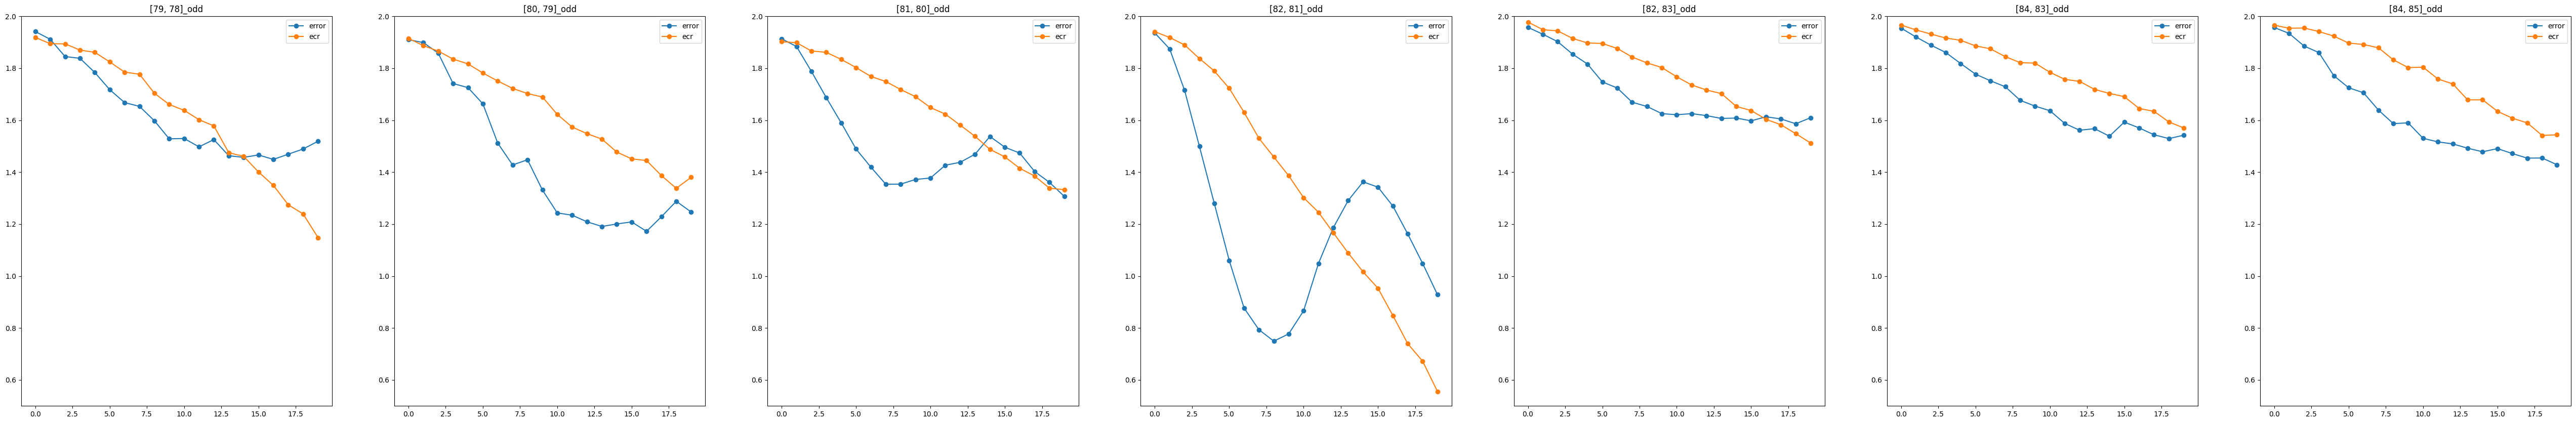

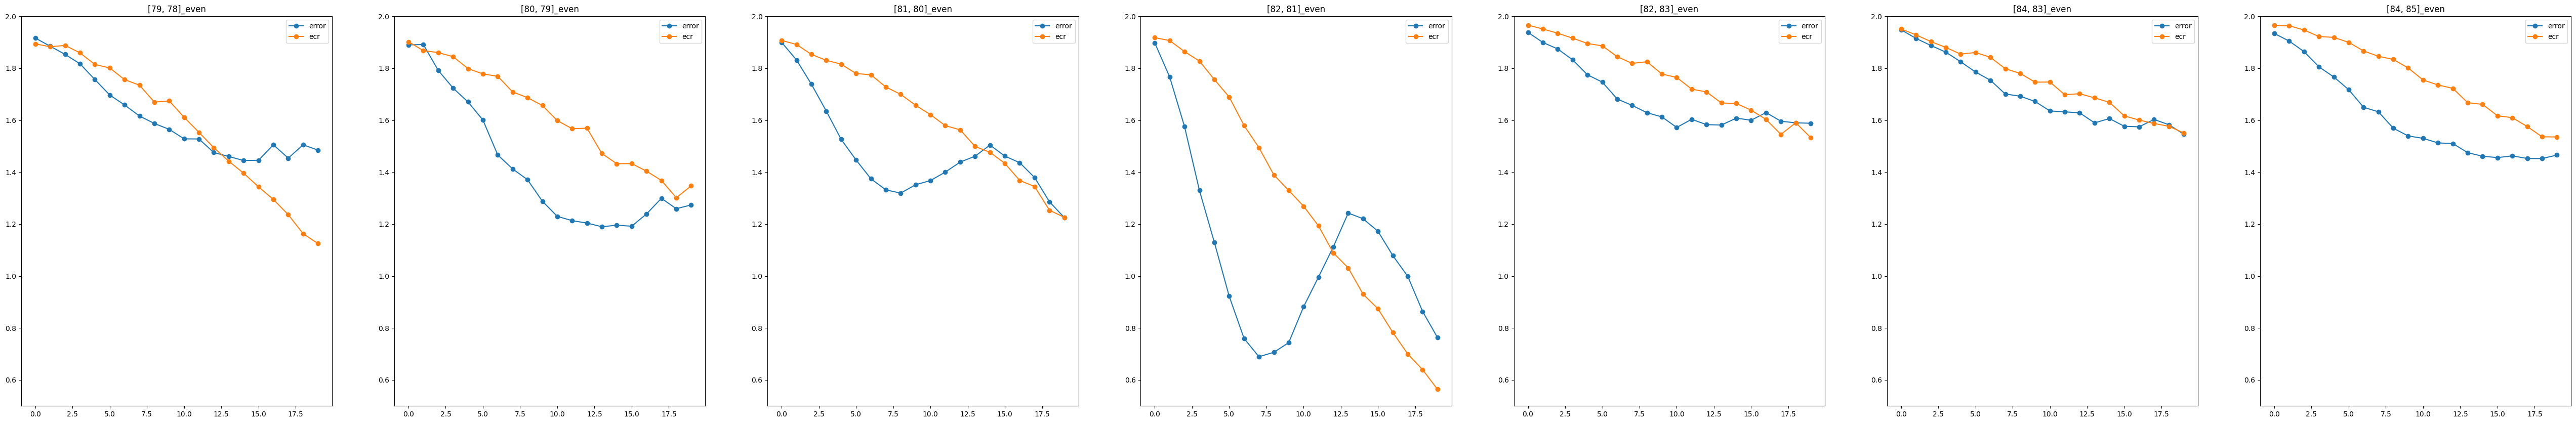

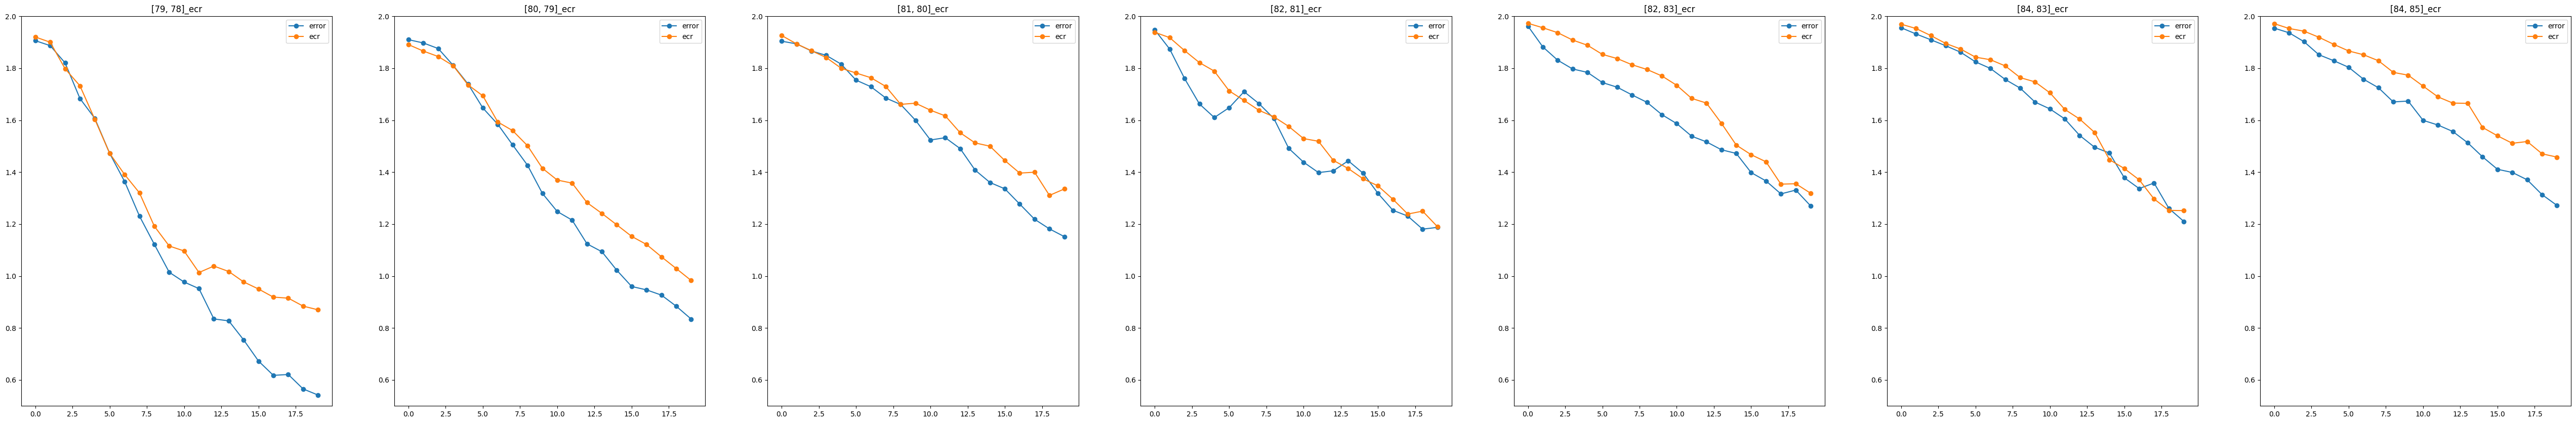

In [12]:
from matplotlib import pyplot as plt
index = 0

for key in data_1.keys():
    if index%7==1:
        plt.figure(figsize=(65,10))
    if index ==0:
        index+=1
        continue
    
    temp_index = index%7
    if temp_index == 0:
        temp_index = 7
    plt.subplot(1,7,temp_index)
    plt.title(key)
    plt.plot(data_1[key],'o-',label='error')
    plt.plot(data_2[key],'o-',label='ecr')
    plt.ylim(0.5,2)
    plt.legend()
    if index%7==0:
        plt.show()
    index+=1
plt.show()

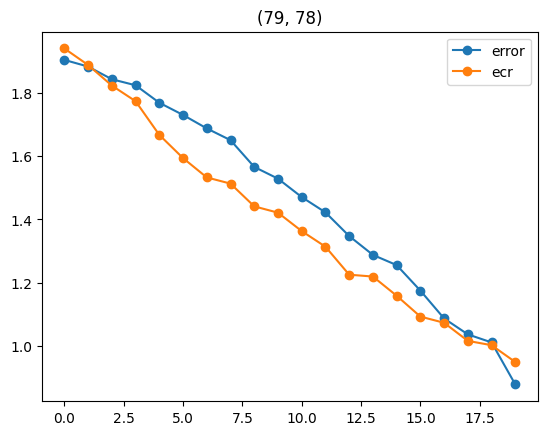

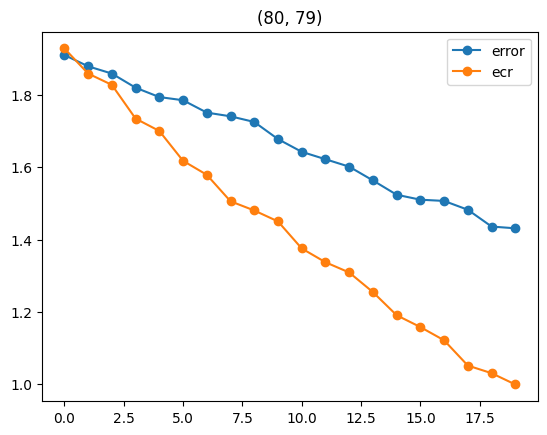

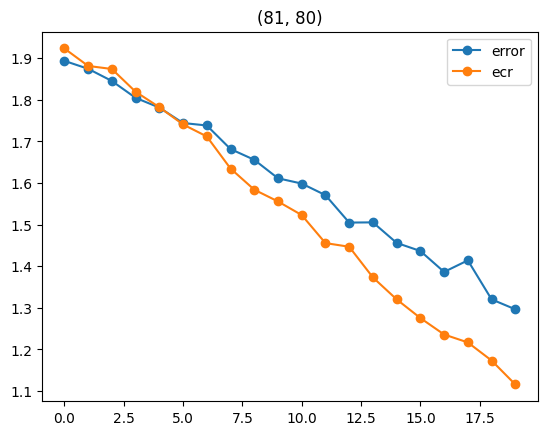

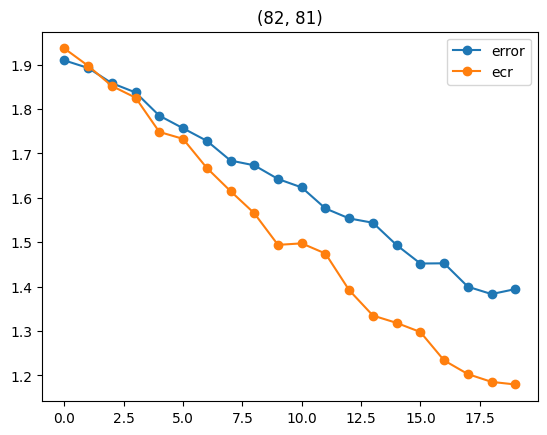

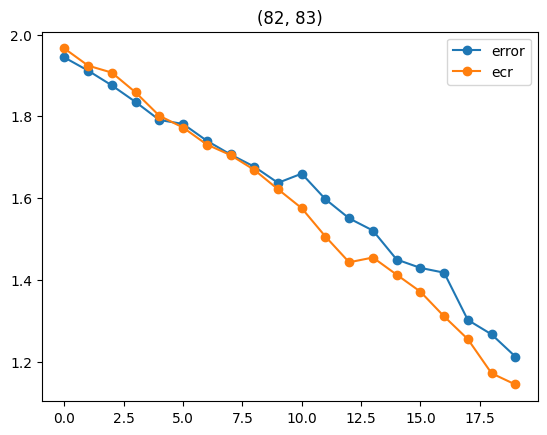

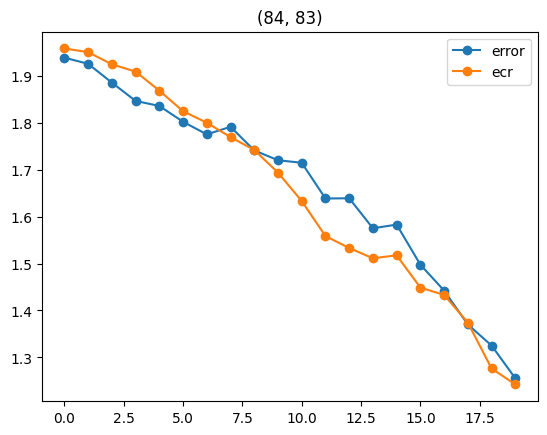

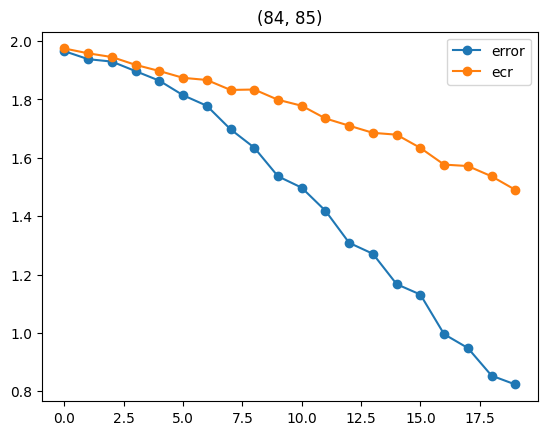

In [13]:

stretch_list = [1]
class_list = []

for stretch in stretch_list:
    config = {'backend':backend,'x_amp_dict':X_dict,'error_stretch':stretch,'ecr_stretch':stretch}
    temp_class = train_ZNE(20,**config)
    temp_class.run()
    class_list.append(temp_class)
for index,class_name in enumerate(class_list):
    result = class_name.get_data()
    plot_result(result,X_dict)
    result.to_csv(f'./ecr_compare_result/high_{stretch_list[index]}_data_{directory}.csv')

In [18]:
backend_temp = temp_class.update_ecr_real()

In [24]:
backend_temp_error = temp_class.update_ecr()

In [28]:
backend_temp.target['ecr'][(79,78)].calibration

ScheduleBlock(ScheduleBlock(Play(GaussianSquare(duration=840, sigma=32, width=712, amp=0.09464928949190077, angle=-2.5422023548891364, name='CR90p_u179'), ControlChannel(179), name='CR90p_u179'), Play(GaussianSquare(duration=840, sigma=32, width=712, amp=0.026093136870041028, angle=0.04107524362462772, name='CR90p_d78_u179'), DriveChannel(78), name='CR90p_d78_u179'), Delay(840, DriveChannel(79)), Delay(120, DriveChannel(78)), Delay(120, ControlChannel(179)), Play(Drag(duration=120, sigma=30, beta=0.07061009278511957, amp=0.19938393703285126, angle=0.0, name='Xp_d79'), DriveChannel(79), name='Xp_d79'), ShiftPhase(3.141592653589793, DriveChannel(78)), ShiftPhase(3.141592653589793, ControlChannel(179)), Play(GaussianSquare(duration=840, sigma=32, width=712, amp=0.09464928949190077, angle=-2.5422023548891364, name='CR90p_u179'), ControlChannel(179), name='CR90p_u179'), Play(GaussianSquare(duration=840, sigma=32, width=712, amp=0.026093136870041028, angle=0.04107524362462772, name='CR90p_d7

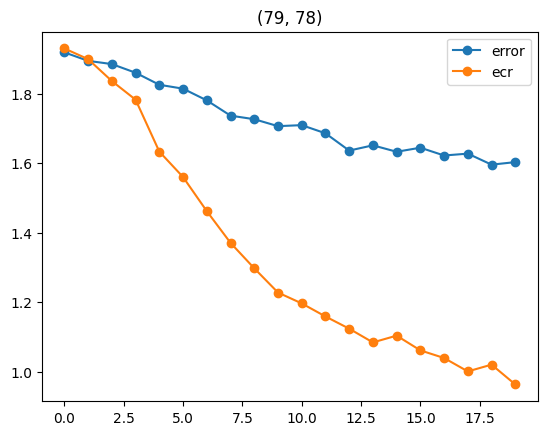

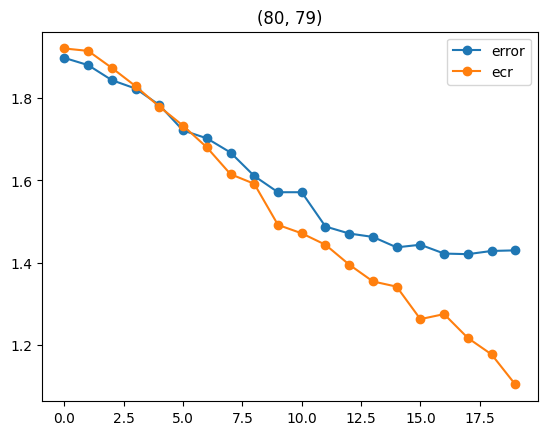

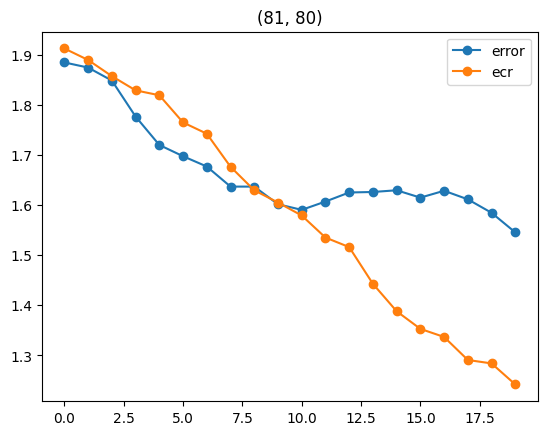

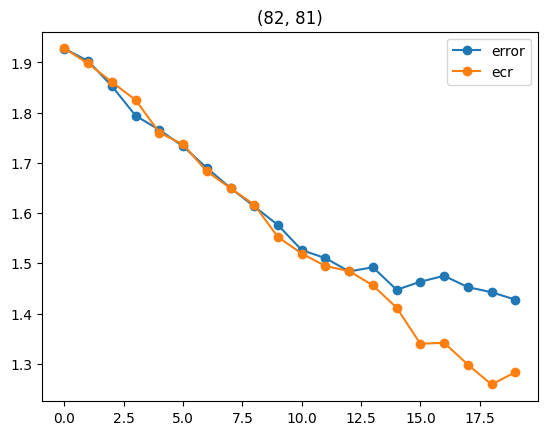

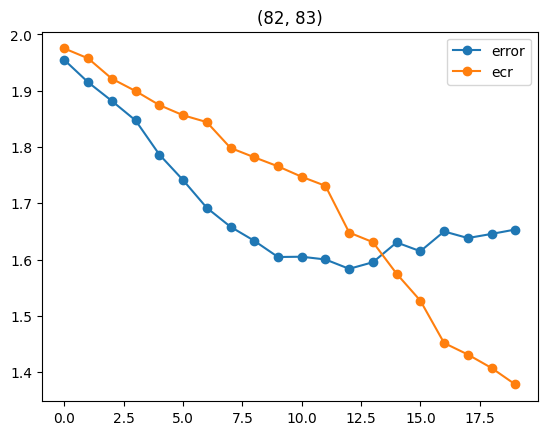

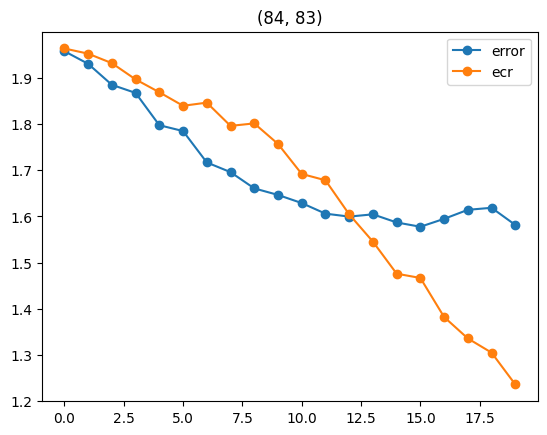

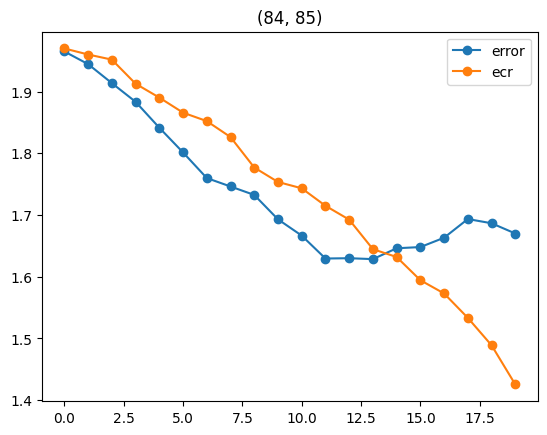

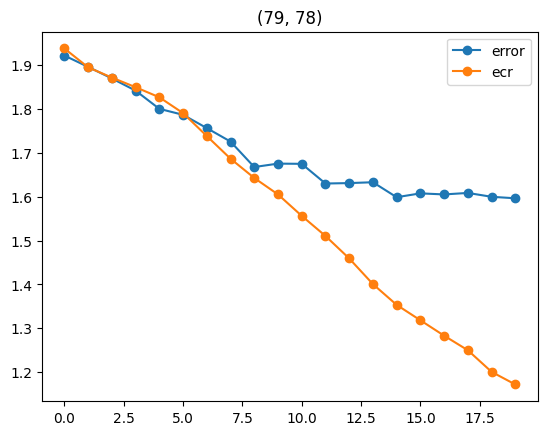

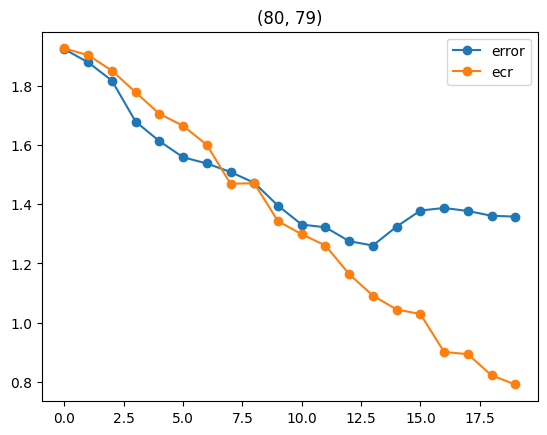

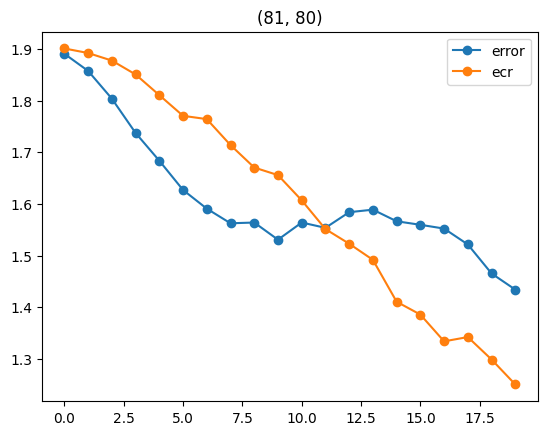

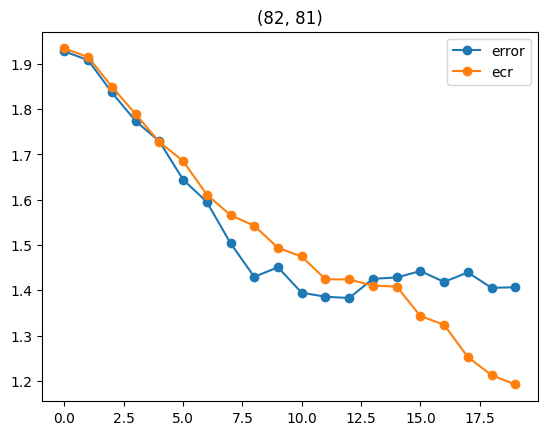

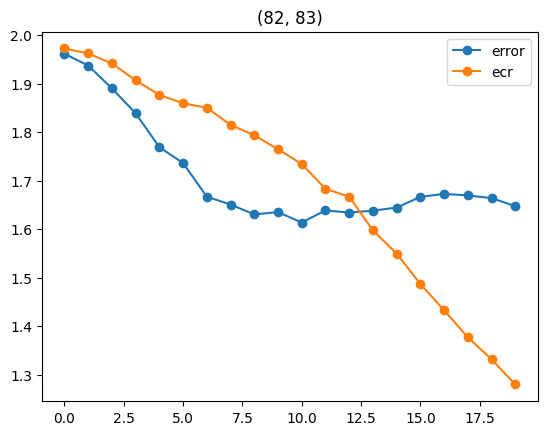

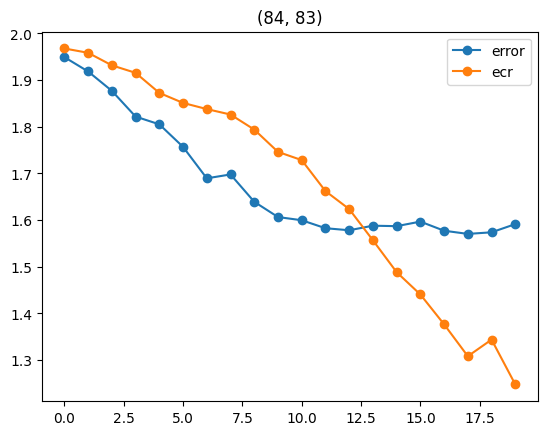

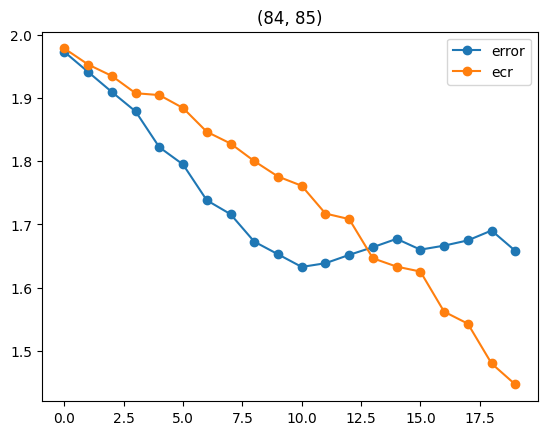

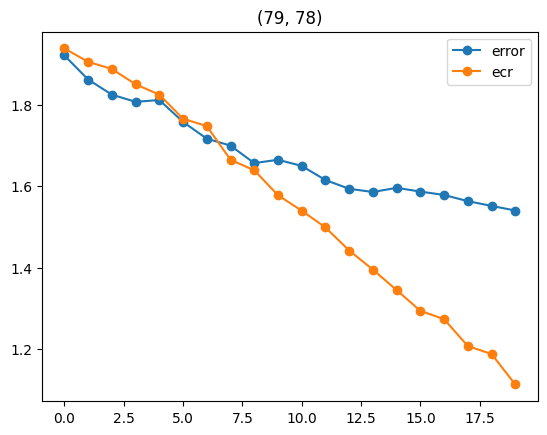

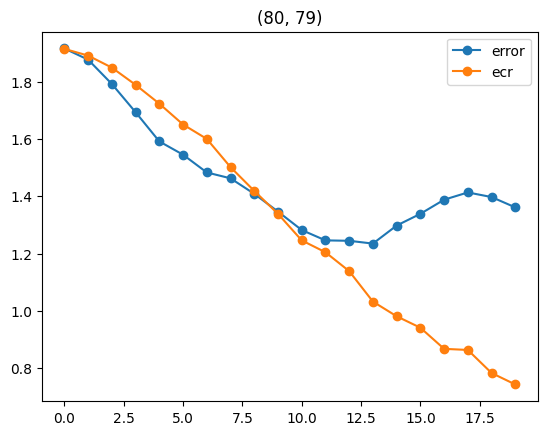

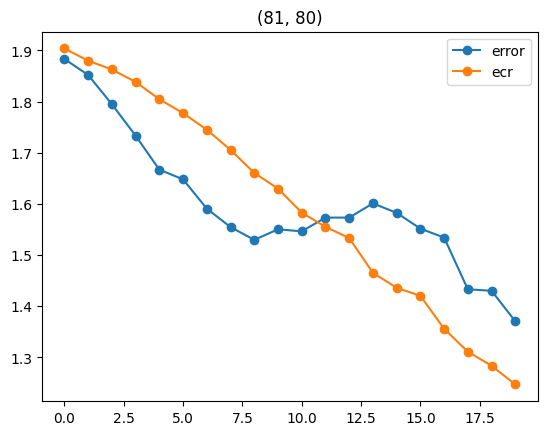

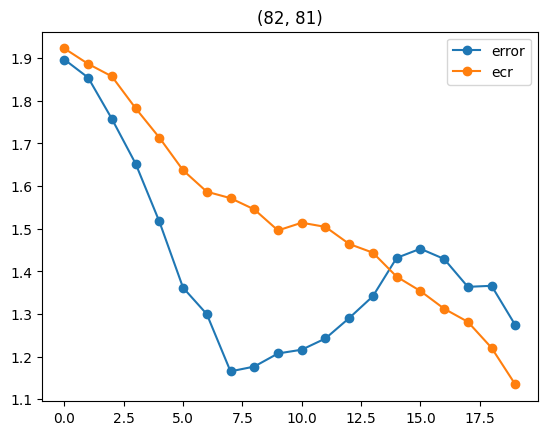

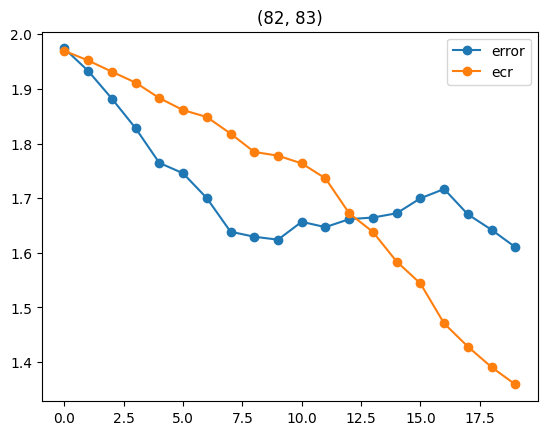

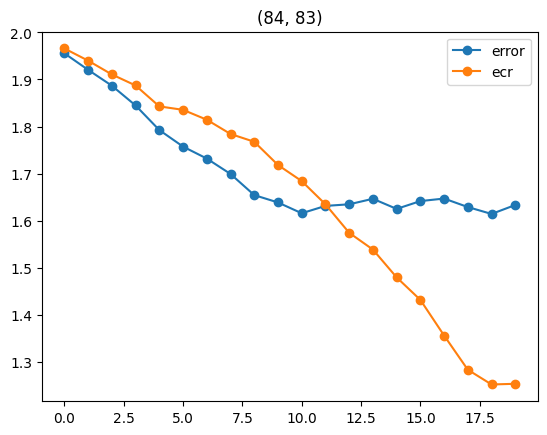

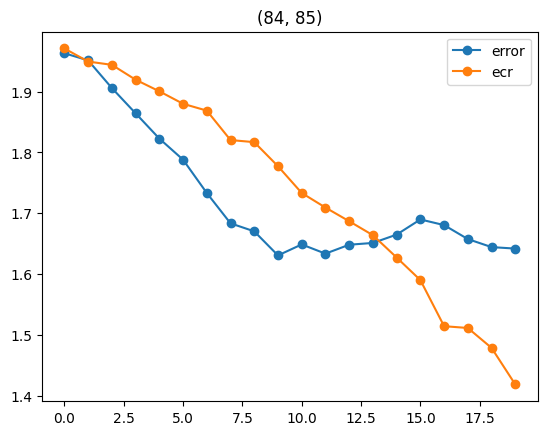

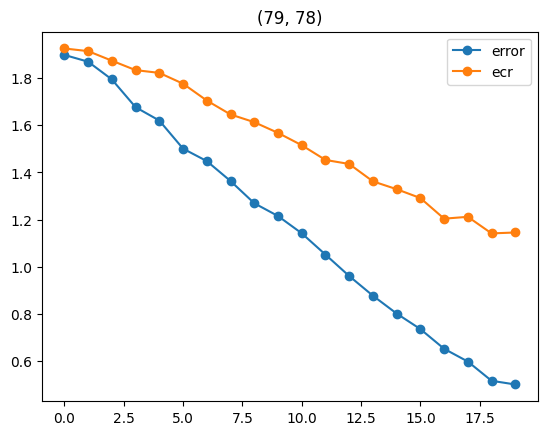

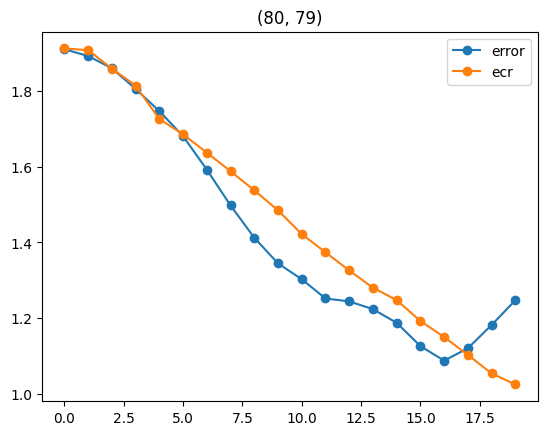

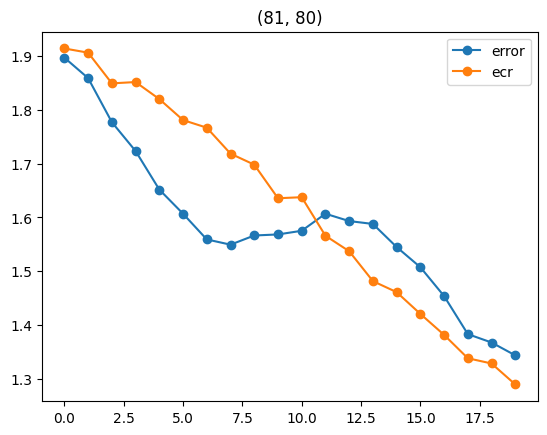

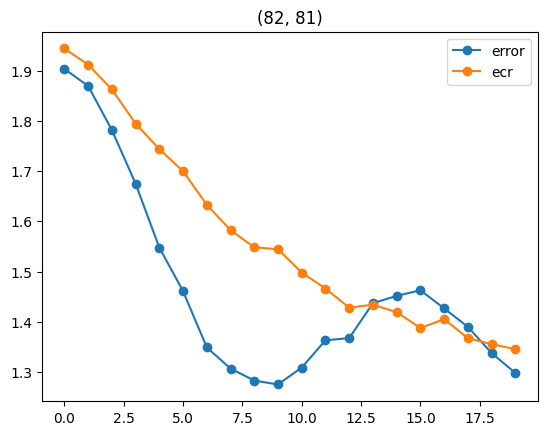

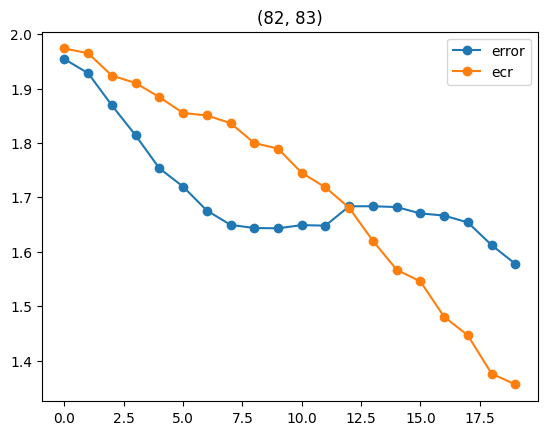

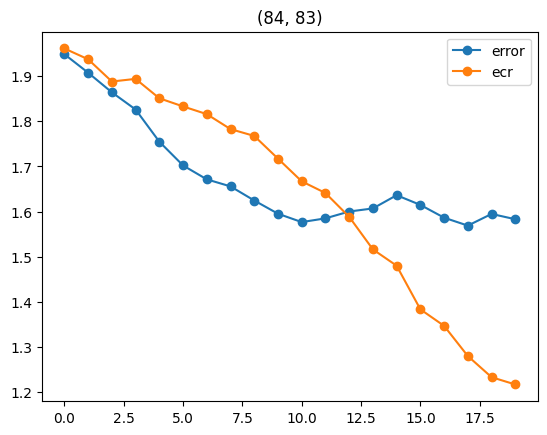

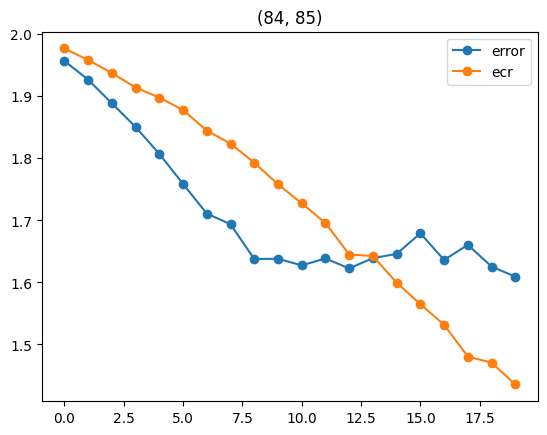

: 

: 

In [34]:
for index,class_name in enumerate(class_list):
    result = class_name.get_data()
    plot_result(result,X_dict)
    result.to_csv(f'./0_ecr_compare_result/{stretch_list[index]}_data_{directory}.csv')

In [8]:
backend_temp = temp_class.update_ecr()

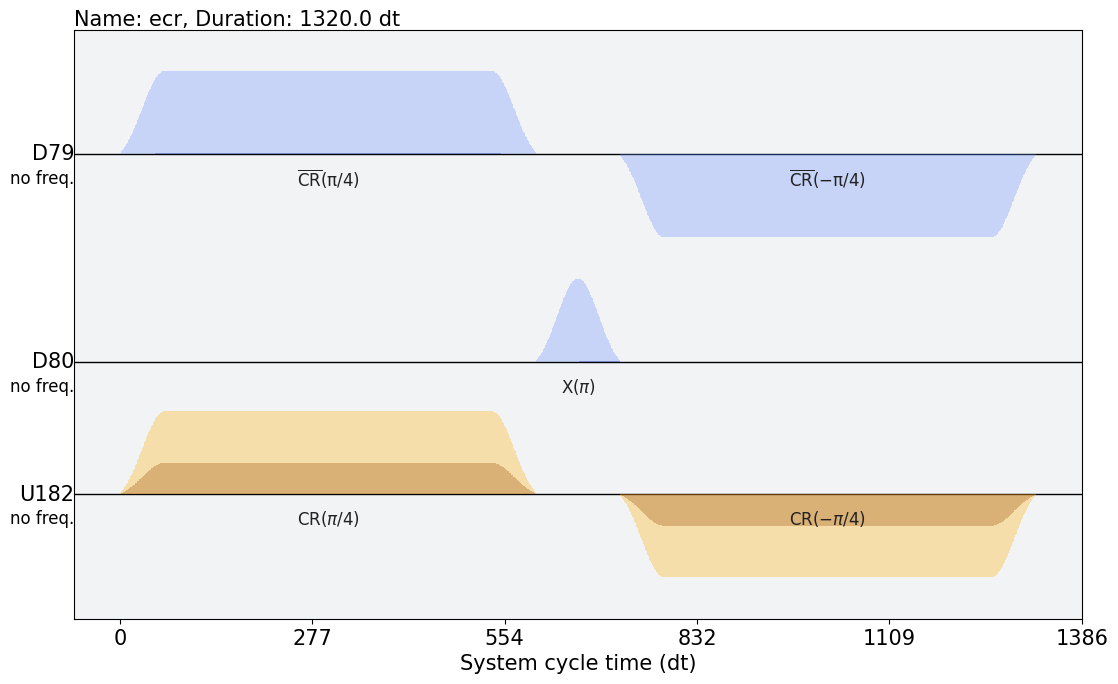

In [9]:
backend.target['ecr'][(80,79)].calibration.draw()

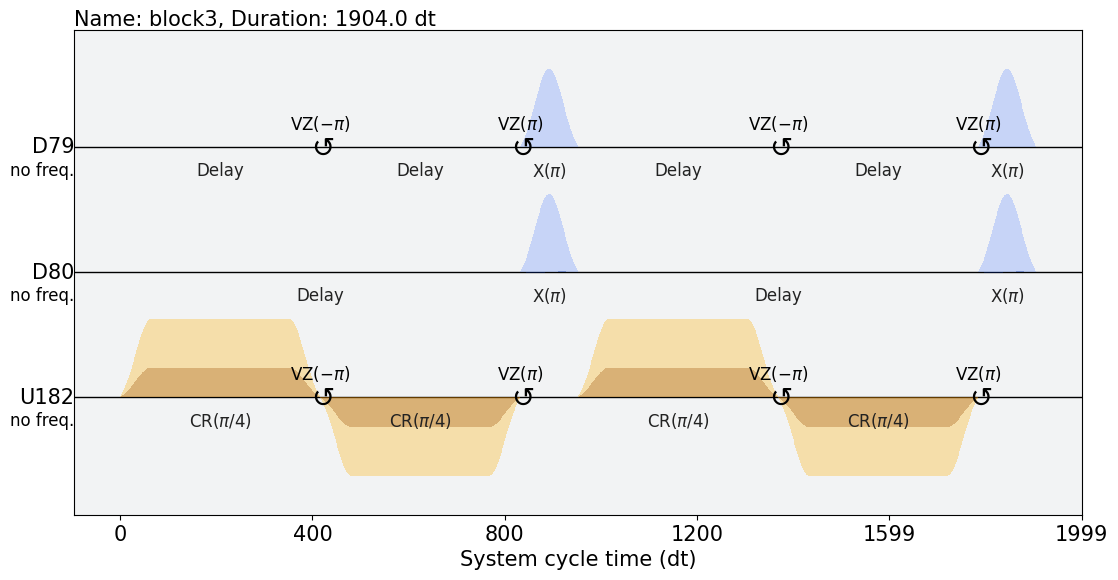

In [10]:
backend_temp.target['ecr'][(80,79)].calibration.draw()